# Identifying spatial niches

A common problem is to identify spatially coherent regions within a tissue sample. This problem is often referred to as identifying spatial niches, or spatial domains; since these are currently used inconsistently within the spatial biology literature, we don't provide an explicit named function to calculate such niches. Instead, the aim of MuSpAn is to provide users with the tools needed to conduct this type of analysis, regardless of the method the user prefers to define these concepts. (We'll also avoid using the phrase "spatial domains" in this context where possible, due to the likelihood of confusing this concept with a MuSpAn domain, which is named for the related mathematical concept of being the region in which functions are defined!)

In this tutorial, we show how MuSpAn can be used alongside standard scientific computing packages in Python to build different workflows for finding spatial niches. We've already seen a couple of examples of this in other tutorials: the tutorial on [community detection in networks](https://docs.muspan.co.uk/latest/_collections/network_analysis/Network%20methods%20-%202%20-%20community_detection.html) meets the criteria of finding spatially coherent regions, but notably this uses only the structure of the data, not any information about the labels. Similarly, [neighbourhood clustering](https://docs.muspan.co.uk/latest/_collections/network_analysis/Network%20methods%20-%204%20-%20neighbourhood_analysis_continuous.html) could be argued to be a form of spatial domain detection, except here we're clustering based on local information about the neighbourhood of the points and not explicitly using their coordinates.

We'll now consider a couple of different approaches to identify spatial niches that use both the locations of cells, and information about their labels. The key to both the tutorials linked above and the examples below is to recognise that "community detection", "neighbourhood analysis", "spatial niches" and "spatial domains" all really refer to the same mathematical processes of identifying clusters in data. As such, the MuSpAn helper function `ms.helpers.cluster_data()` is going to be our friend here!

### Choosing a domain

Let's work with the Xenium example dataset, as it has plenty of interesting labels associated with it. For the sake of doing clustering, we'll add the number of transcripts of each type per cell here as well (you can export this directly from Xenium if you prefer).

MuSpAn domain loaded successfully. Domain summary:
Domain name: Xenium-Healthy-Colon
Number of objects: 74174
Collections: ['Cell boundaries', 'Nucleus boundaries', 'Transcripts']
Labels: ['Cell ID', 'Transcript Counts', 'Cell Area', 'Cluster ID', 'Nucleus Area', 'Transcript', 'Transcript ID'] 
Networks: [] 
Distance matrices: []
Domain temp_example_domain exported as csv successfully to ..


(<Figure size 1000x800 with 2 Axes>, <Axes: >)

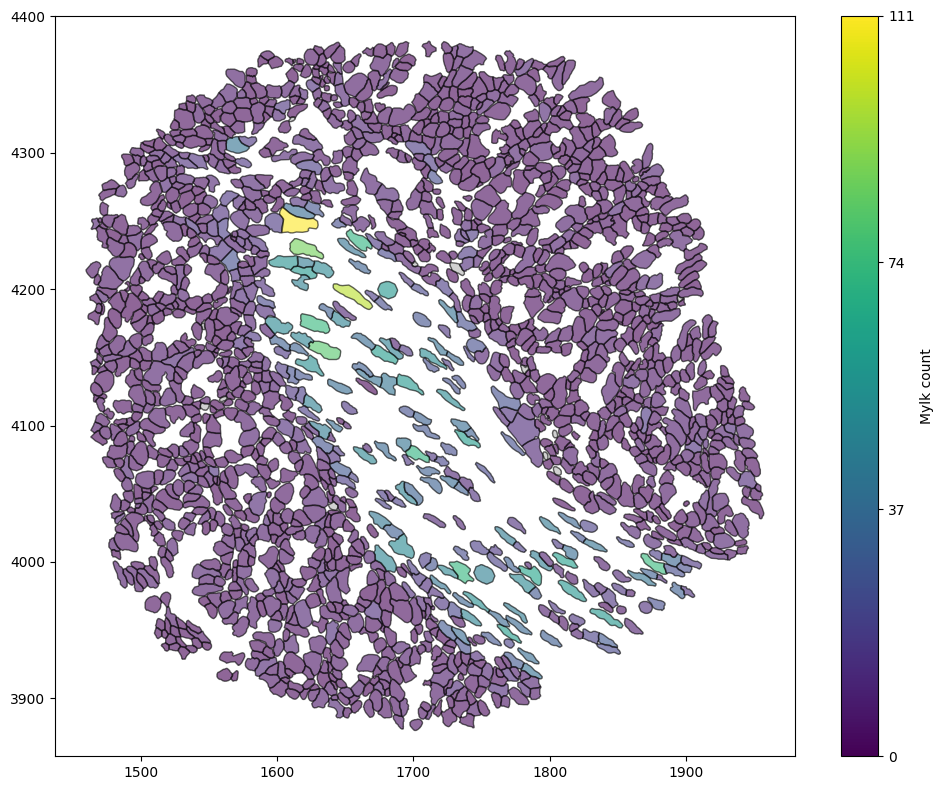

In [4]:
import muspan as ms
import numpy as np

domain = ms.datasets.load_example_domain('Xenium-Healthy-Colon')

# Count the number of each transcript within each cell, and add it as a label
# This is just because I want some nice numerical data to do clustering on, you can actually get 
# this information directly from Xenium explorer if you import using ms.io.xenium_to_domain
#
# So feel free to ignore this step if you're only really interested in funding spatial niches from your own dataset!

# First, convert the domain to a dataframe
domain_df = ms.io.domain_to_csv(domain, name_of_file='temp_example_domain', path_to_save='.', return_dataframe=True)

# Use some standard Pandas to get the number of cell counts per cell
result = (domain_df[domain_df["Transcripts"]]
          .groupby(["Transcript ID", "Cell ID"])
          .size()
          .unstack(fill_value=0)
          .to_dict(orient="index"))

# Now get the object ID of each cell boundary corresponding to these Cell IDs
cellID_to_boundary_objectID = (
    domain_df.loc[domain_df["Cell boundaries"], ["Cell ID", "object_id"]]
    .set_index("Cell ID")["object_id"]
    .to_dict()
)

# Fancy dictionary comprehension to line these up
transcript_to_counts_and_objects = {
    tid: {
        "object_ids": [cellID_to_boundary_objectID.get(cid) for cid in cell_counts],
        "counts": np.array(list(cell_counts.values()),dtype=float)
    }
    for tid, cell_counts in result.items()
}

# Now add them as labels
transcript_names = []
for tid, cell_data in transcript_to_counts_and_objects.items():
    transcript_names.append(tid)
    domain.add_labels(f'{tid} count', cell_data['counts'],add_labels_to=cell_data['object_ids'])

ms.visualise.visualise(domain, 'Mylk count',objects_to_plot=('collection','Cell boundaries'))



Great, now that we've added the transcript counts to each cell boundary we can just think about those. (Please feel free to ignore the process of adding them here - this can be done when importing from Xenium, but the transcript counts just aren't present in our example domain at the moment.)

### Approach 1: naive spatial and label clustering

One approach to including both spatial information and label information in assigning clusters is to naively concatenate them into the same feature vector. Let's extract the relevant information from our MuSpAn domain and see what this looks like.

For simplicity, let's limit our domain to cells and their various transcript labels. Let's bring the centroids and labels explicitly into the Python workspace.

In [10]:
centroids, centroid_object_IDs = ms.query.get_centroids(domain, ('collection','Cell boundaries'))

transcript_label_values = {}
for transcript in transcript_names:
    labels, label_object_IDs = ms.query.get_labels(domain, f'{transcript} count')
    transcript_label_values[transcript] = (labels, label_object_IDs)

Now let's build a pandas DataFrame, indexed by the object IDs of cell boundaries, to make sure that we're associating the right centroid with the right labels. Notice that we're now working outside MuSpAn using other packages in the Python workspace: MuSpAn is designed to keep the Python workspace clean by keeping a lot of helper Python objects inside a single `domain` object, while letting us access them if we want to so that we can use the strength of the vast Python scientific computing ecosystem to let us do whatever we like!

In [13]:
import pandas as pd

df = pd.DataFrame({
    "object_ID": centroid_object_IDs,
    "x": [c[0] for c in centroids],
    "y": [c[1] for c in centroids],
}).set_index("object_ID")

for transcript, (counts, obj_ids) in transcript_label_values.items():
    s = pd.Series(counts, index=obj_ids)
    df[transcript] = s


print(df.head())


                     x            y  Ccl9  Cldn2  Cnn1  Mgll  Mustn1  Myl9  \
object_ID                                                                    
0          1892.425392  4126.537829   0.0    2.0   0.0   1.0     0.0   0.0   
1          1825.590240  4151.220509   1.0    9.0   0.0   0.0     0.0   0.0   
2          1911.706793  4142.200254   0.0    0.0   0.0   7.0     0.0   0.0   
3          1928.371517  4130.492303   0.0    2.0   0.0   5.0     0.0   0.0   
4          1918.546718  4154.509941   0.0    0.0   0.0   6.0     0.0   0.0   

           Mylk  Nupr1  Oit1  Sox9  
object_ID                           
0           1.0    3.0   9.0   0.0  
1           0.0    6.0   9.0   2.0  
2           4.0    1.0   7.0   1.0  
3           1.0    6.0   9.0   0.0  
4           2.0    0.0   7.0   0.0  


Great, we have a DataFrame. Now let's do some clustering! For simplicity, we'll use MuSpAn's `cluster_data()` method, but this essentially provides a wrapper for other common Python tools like `scikit-learn` which you could use instead. Or, of course, you could use any other library you like!

(<Figure size 1000x800 with 2 Axes>, <Axes: >)

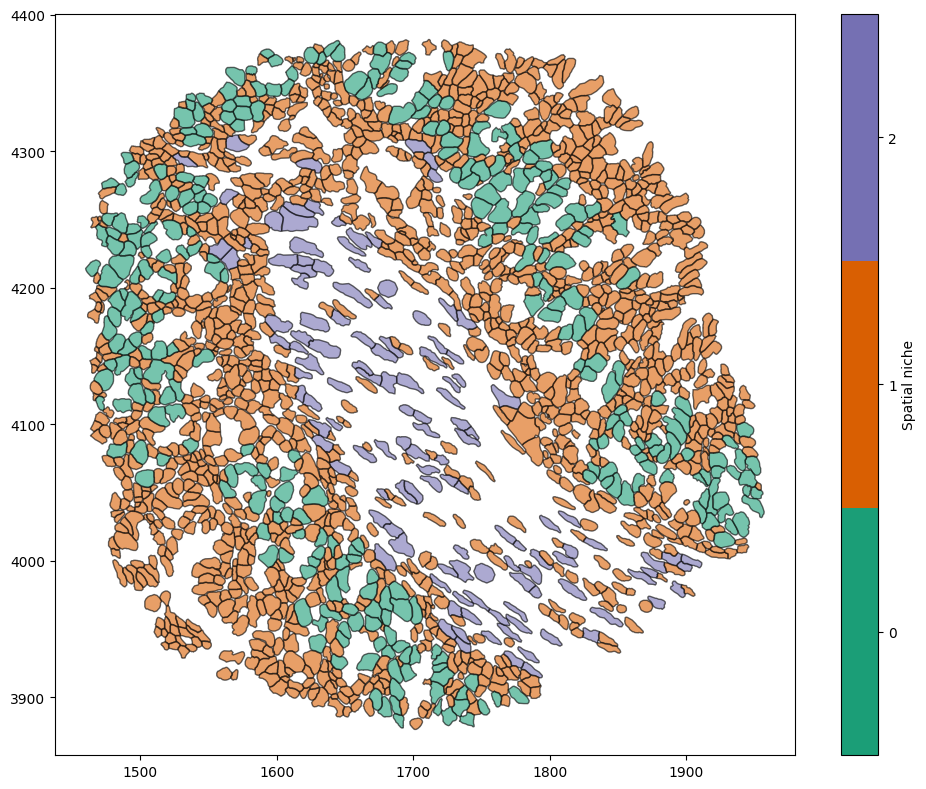

In [30]:
cluster_on = [v for v in df.columns if v not in ['object_ID']]
data = df[cluster_on].to_numpy()
data = np.nan_to_num(data, nan=0)

# Since the (x,y) coordinates are so much larger than the transcript counts, they'll dominate
# Let's normalise data first
data = (data - data.mean(axis=0)) / data.std(axis=0)

cluster_object = ms.helpers.cluster_data(data, method='kmeans', n_clusters=3)

# Add the resulting cluster labels to the domain object
domain.add_labels(
    label_name='Spatial niche',  # Name of the new label
    labels=cluster_object.labels_,  # Cluster labels
    add_labels_to=centroid_object_IDs,  # Where to add the labels
    cmap='Dark2'  # Colormap for the labels
)

ms.visualise.visualise(domain, 'Spatial niche', objects_to_plot=('collection','Cell boundaries'))